# Background Information

The game of soccer is continuous in time but decisions are discrete. We can treat a match as an ordered sequence of events: match = [e1, e2, ... ] where each event has its own structure and contextual field

The main research question I'd like to address is how we can leverage graph theory and network analysis combined with deep learning to analyze player similarity. Football passing structure can naturaly be represented as a directed graph G = (V,E) where the set of nodes V represents players and E represents passes. In this EDA I hope to understand how all of the statsbomb data works together, and ultimately be able to model this graph as input for a graph neural network (GNN).

Some sources referenced: 
- https://paulminogue.com/posts/375ea85d-fc58-4c13-a9dc-5a45ba3c368f
- https://github.com/minoguep/graph_neural_networks/blob/master/graph_neural_network_data_preparation.ipynb
- https://www.youtube.com/watch?v=7JELX6DiUxQ
- https://www.nature.com/articles/s41467-024-45965-x
- https://medium.com/@lucascarrasquillaparra/complete-guide-on-working-with-the-statsbomb-open-data-dataset-a57c26d5852b


# Import Packages

In [107]:
%matplotlib inline

import json
import os
import pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from datetime import date

# Data Exploration
Data overview:

Competition

-> Season

    -> Match

        -> events
        -> lineups
        -> 360
        
General steps:
- obtain and explore match data (describes all of the matches including the tournament, the teams playing, final scores, etc)
- then we want to get the event data for each match (join on match_id) and explore the information available for a given "event" during a match

In [191]:
import json
from pathlib import Path
import pandas as pd

def load_competitions(repo_root: str | Path) -> tuple[pd.DataFrame, dict]:
    """
    Load StatsBomb Open Data competitions.json and return:
      (1) competitions dataframe
      (2) a small summary dict you can print or log

    Parameters
    ----------
    repo_root : str | Path
        Path to the *root* of the statsbomb/open-data repository clone.

    Returns
    -------
    competitions_df : pd.DataFrame
    summary : dict
    """
    repo_root = Path(repo_root)
    comp_path = repo_root / "data" / "competitions.json"

    if not comp_path.exists():
        raise FileNotFoundError(
            f"Could not find {comp_path}. "
            "Make sure repo_root points to the cloned statsbomb/open-data directory."
        )

    competitions_data = json.loads(comp_path.read_text(encoding="utf-8"))
    competitions_df = pd.DataFrame(competitions_data)

    # These column names are stable in the open-data schema (gender was added in v1.1). :contentReference[oaicite:5]{index=5}
    summary = {
        "entries_competitions_json": len(competitions_df),  # competition-season entries
        "unique_competitions": competitions_df["competition_name"].nunique(),
        "unique_seasons": competitions_df["season_name"].nunique(),
        "countries": competitions_df["country_name"].nunique(),
        "genders": competitions_df["competition_gender"].value_counts(dropna=False).to_dict(),
    }

    return competitions_df, summary


# Example usage
competitions_df, summary = load_competitions(r"statsbomb_data")

print("=== DATASET SCOPE (local copy) ===")
for k, v in summary.items():
    print(f"{k}: {v}")

# Quick look at what fields you have
print("\nColumns:", sorted(competitions_df.columns))
print("\nSample rows:")
print(competitions_df.head(3))

=== DATASET SCOPE (local copy) ===
entries_competitions_json: 75
unique_competitions: 21
unique_seasons: 48
countries: 13
genders: {'male': 67, 'female': 8}

Columns: ['competition_gender', 'competition_id', 'competition_international', 'competition_name', 'competition_youth', 'country_name', 'match_available', 'match_available_360', 'match_updated', 'match_updated_360', 'season_id', 'season_name']

Sample rows:
   competition_id  season_id country_name        competition_name  \
0               9        281      Germany           1. Bundesliga   
1               9         27      Germany           1. Bundesliga   
2            1267        107       Africa  African Cup of Nations   

  competition_gender  competition_youth  competition_international  \
0               male              False                      False   
1               male              False                      False   
2               male              False                       True   

  season_name             

In [192]:
import numpy as np
import pandas as pd

def analyze_competition_hierarchy(competitions_df: pd.DataFrame) -> dict:
    """
    Summarize the competition→season hierarchy encoded in competitions.json.

    Returns a dict so you can log it, print it, or reuse it in later sections.
    """
    comp_counts = competitions_df["competition_name"].value_counts()

    seasons_per_comp = comp_counts.to_numpy()

    summary = {
        "top_competitions_by_seasons": comp_counts.head(10),
        "seasons_per_competition": {
            "mean": float(np.mean(seasons_per_comp)),
            "median": float(np.median(seasons_per_comp)),
            "std": float(np.std(seasons_per_comp, ddof=0)),
            "min": int(np.min(seasons_per_comp)),
            "max": int(np.max(seasons_per_comp)),
        }
    }

    print("=== COMPETITION HIERARCHY (local copy) ===")
    print("Top competitions by number of seasons available:")
    for comp, n in summary["top_competitions_by_seasons"].items():
        print(f"  {comp}: {n}")

    stats = summary["seasons_per_competition"]
    print("\nSeasons per competition (distribution summary):")
    print(f"  mean={stats['mean']:.2f} | median={stats['median']:.2f} | std={stats['std']:.2f} | min={stats['min']} | max={stats['max']}")

    return summary

hierarchy_summary = analyze_competition_hierarchy(competitions_df)

=== COMPETITION HIERARCHY (local copy) ===
Top competitions by number of seasons available:
  Champions League: 18
  La Liga: 18
  FIFA World Cup: 8
  Ligue 1: 3
  Copa del Rey: 3
  FA Women's Super League: 3
  1. Bundesliga: 2
  UEFA Women's Euro: 2
  UEFA Euro: 2
  Serie A: 2

Seasons per competition (distribution summary):
  mean=3.57 | median=2.00 | std=4.91 | min=1 | max=18


In [193]:
def analyze_360_coverage(competitions_df):
    """
    Analyze StatsBomb 360 data availability and coverage patterns.
    
    Returns:
    dict: 360 data coverage statistics and patterns
    """
    # Identify competitions with 360 data
    has_360 = competitions_df[competitions_df['match_available_360'].notna()]
    
    print("=== STATSBOMB 360 DATA COVERAGE ===")
    print(f"Competitions with 360 data: {len(has_360)} / {len(competitions_df)} ({100*len(has_360)/len(competitions_df):.1f}%)")
    
    if len(has_360) > 0:
        print("\nCompetitions with 360 data:")
        for _, row in has_360.iterrows():
            print(f"  {row['competition_name']} {row['season_name']}")
        
        # Temporal analysis of 360 data availability
        has_360['year'] = has_360['season_name'].str.extract('(\d{4})', expand=False).astype(float)
        year_analysis = has_360.groupby('year').size()
        
        print(f"\n360 Data Temporal Distribution:")
        for year, count in year_analysis.items():
            if not np.isnan(year):
                print(f"  {int(year)}: {count} competitions")
    
    return {
        'total_360_competitions': len(has_360),
        'coverage_percentage': 100 * len(has_360) / len(competitions_df),
        '360_competitions': has_360[['competition_name', 'season_name', 'match_available_360']]
    }

coverage_360 = analyze_360_coverage(competitions)

<>:20: SyntaxWarning: invalid escape sequence '\d'
<>:20: SyntaxWarning: invalid escape sequence '\d'
C:\Users\sophi\AppData\Local\Temp\ipykernel_34608\3024524011.py:20: SyntaxWarning: invalid escape sequence '\d'
  has_360['year'] = has_360['season_name'].str.extract('(\d{4})', expand=False).astype(float)
C:\Users\sophi\AppData\Local\Temp\ipykernel_34608\3024524011.py:20: SyntaxWarning: invalid escape sequence '\d'
  has_360['year'] = has_360['season_name'].str.extract('(\d{4})', expand=False).astype(float)


TypeError: tuple indices must be integers or slices, not str

In [ ]:
def analyze_match_structure(data_path, competition_id=11, season_id=90):
    """
    Analyze match-level data structure for a specific competition-season pair.
    
    Parameters:
    data_path (str): Path to StatsBomb data
    competition_id (int): Competition identifier
    season_id (int): Season identifier
    
    Returns:
    dict: Match structure analysis with schema information
    """
    matches_path = Path(data_path) / "data" / "matches" / str(competition_id) / f"{season_id}.json"
    
    if not matches_path.exists():
        return {"error": f"Matches file not found: {matches_path}"}
    
    with open(matches_path, 'r', encoding='utf-8') as f:
        matches_data = json.load(f)
    
    matches_df = pd.DataFrame(matches_data)
    
    print("=== MATCH STRUCTURE ANALYSIS ===")
    print(f"Competition ID: {competition_id}, Season ID: {season_id}")
    print(f"Total matches: {len(matches_df)}")
    print(f"Schema columns: {list(matches_df.columns)}")
    
    # Analyze match metadata
    if len(matches_df) > 0:
        sample_match = matches_df.iloc[0]
        print(f"\nSample Match Metadata:")
        print(f"  Match ID: {sample_match.get('match_id')}")
        print(f"  Date: {sample_match.get('match_date')}")
        print(f"  Kick-off: {sample_match.get('kick_off')}")
        
        # Extract team information
        home_team = sample_match.get('home_team', {})
        away_team = sample_match.get('away_team', {})
        print(f"  Home team: {home_team.get('home_team_name', 'Unknown')}")
        print(f"  Away team: {away_team.get('away_team_name', 'Unknown')}")
        
        # Temporal analysis
        if 'match_date' in matches_df.columns:
            dates = pd.to_datetime(matches_df['match_date'])
            print(f"\nTemporal Coverage:")
            print(f"  Date range: {dates.min().date()} to {dates.max().date()}")
            print(f"  Duration: {(dates.max() - dates.min()).days} days")
    
    return {
        "matches_df": matches_df,
        "total_matches": len(matches_df),
        "schema_columns": list(matches_df.columns)
    }


# Example: Analyze La Liga 2020/21 season
match_structure = analyze_match_structure("path/to/data", competition_id=11, season_id=90)
match_structure

{'error': 'Matches file not found: path\\to\\data\\data\\matches\\11\\90.json'}

: 

In [99]:
# look at specific sample to understand available data for each match
with open('statsbomb_data/data/matches/2/27.json', 'r') as f:
    sample_match = json.load(f)

print(sample_match[0].keys())

dict_keys(['match_id', 'match_date', 'kick_off', 'competition', 'season', 'home_team', 'away_team', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'metadata', 'match_week', 'competition_stage', 'stadium', 'referee'])


Potentially useful match information (for the purpose of our research question)
- match_id
- match_date
- competition: competition_name
- season: season_name
- home_team: home_team_id, home_team_name
- away_team: away_team_id, away_team_name
- home_score
- away_score

In [110]:
# aggregate all match data across all files
matches_dir = 'statsbomb_data/data/matches'
match_data = []

for subdir, dir, files in os.walk(matches_dir):
    for file in files:
        with open(os.path.join(subdir, file)) as json_file:
            matches = json.load(json_file)
            # append all "useful" information as defined above
            for match in matches:
                match_data.append(
                        {
                            'match_id': match['match_id'],
                            'match_date': match['match_date'],
                            'competition': match['competition']['competition_name'],
                            'season': match['season']['season_name'],
                            'home_team_id': match['home_team']['home_team_id'],
                            'home_team': match['home_team']['home_team_name'],
                            'away_team': match['away_team']['away_team_name'],
                            'away_team_id': match['away_team']['away_team_id'],
                            'home_score': match['home_score'],
                            'away_score': match['away_score'],
                        })
            
match_df = pd.DataFrame(match_data)

In [111]:
# some cleaning: convert match_date to datetime, match_id should be unique so set to index
print(match_df.dtypes)
print(match_df['match_id'].is_unique)
match_df['match_date'] = pd.to_datetime(match_df['match_date'])
match_df = match_df.set_index('match_id')

match_id         int64
match_date      object
competition     object
season          object
home_team_id     int64
home_team       object
away_team       object
away_team_id     int64
home_score       int64
away_score       int64
dtype: object
True


Some questions I'd like to know about the match data:
- how many matches, competitions, seasons are there?
- are there dates/periods of the year that have significantly more matches than others?
- do the distribution of scores differ significantly across competitions

In [122]:
print(f'Match data available from {min((match_df['match_date']).dt.year)} to {max((match_df['match_date']).dt.year)}\n')
print(f'Total number of matches: {len(match_df)}\n')
print(f'Total number of competitions: {len(set(match_df['season']))}\n')

print('Competitions by Season:')

with pd.option_context('display.max_rows', None, 
                       'display.max_columns', None, 
                       'display.max_colwidth', None):
    display(match_df.groupby(['competition', 'season']).size().to_frame('count'))

Match data available from 1958 to 2025

Total number of matches: 3464

Total number of competitions: 48

Competitions by Season:


count
competition             season          
1. Bundesliga           2015/2016    306
                        2023/2024     34
African Cup of Nations  2023          52
Champions League        1970/1971      1
                        1971/1972      1
                        1972/1973      1
                        1999/2000      1
                        2003/2004      1
                        2004/2005      1
                        2006/2007      1
                        2008/2009      1
                        2009/2010      1
                        2010/2011      1
                        2011/2012      1
                        2012/2013      1
                        2013/2014      1
                        2014/2015      1
                        2015/2016      1
                        2016/2017      1
                        2017/2018      1
                        2018/2019      1
Copa America            2024          32
Copa del Rey            1977/1978      1
                        1982/1983      1
                        1983/1984      1
FA Women's Super League 2018/2019    108
                        2019/2020     87
                        2020/2021    131
FIFA U20 World Cup      1979           1
FIFA World Cup          1958           2
                        1962           1
                        1970           6
                        1974           6
                        1986           3
                        1990           1
                        2018          64
                        2022          64
Indian Super league     2021/2022    115
La Liga                 1973/1974      1
                        2004/2005      7
                        2005/2006     17
                        2006/2007     26
                        2007/2008     28
                        2008/2009     31
                        2009/2010     35
                        2010/2011     33
                        2011/2012     37
                        2012/2013     32
                        2013/2014     31
                        2014/2015     38
                        2015/2016    380
                        2016/2017     34
                        2017/2018     36
                        2018/2019     34
                        2019/2020     33
                        2020/2021     35
Liga Profesional        1981           1
                        1997/1998      1
Ligue 1                 2015/2016    377
                        2021/2022     26
                        2022/2023     32
Major League Soccer     2023           6
NWSL                    2018          36
North American League   1977           1
Premier League          2003/2004     38
                        2015/2016    380
Serie A                 1986/1987      1
                        2015/2016    380
UEFA Euro               2020          51
                        2024          51
UEFA Europa League      1988/1989      3
UEFA Women's Euro       2022          31
                        2025          31
Women's World Cup       2019          52
                        2023          64

C:\Users\sophi\AppData\Local\Temp\ipykernel_34608\3685173416.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


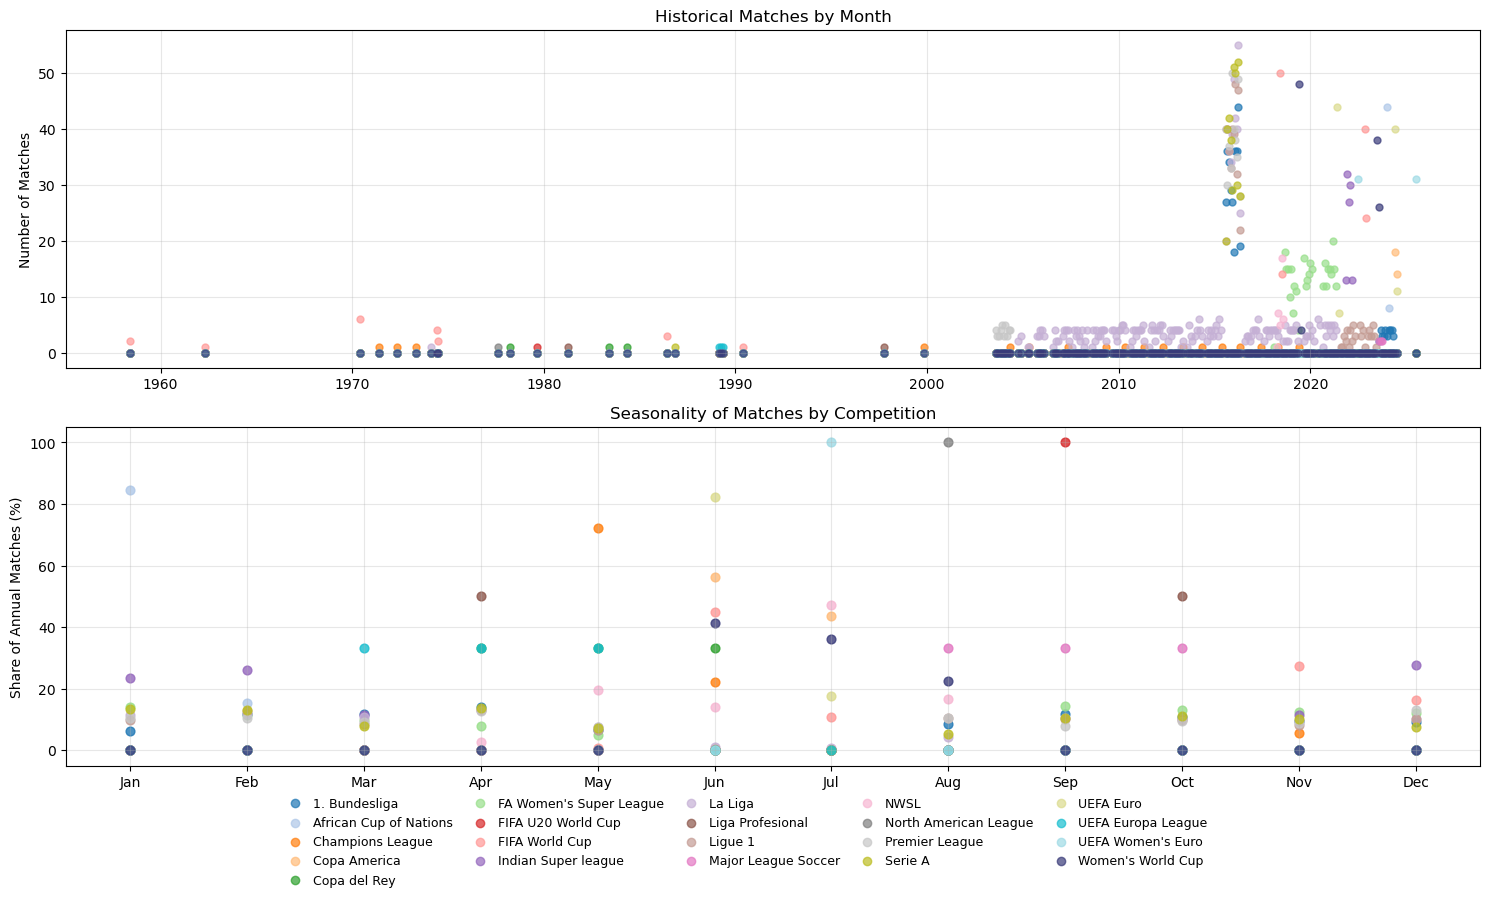

In [138]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.cm as cm


# get into proper format for counts
match_df['match_month'] = match_df['match_date'].dt.to_period('M') # get month-year
match_df['calendar_month'] = match_df['match_date'].dt.month # get just month


# get monthly match count for each competition
monthly_counts = (
    match_df.groupby(['match_month', 'competition'])
      .size()
      .unstack(fill_value=0)
)
monthly_counts.index = monthly_counts.index.to_timestamp()


# normalize to percentage of yearly total (per competition)
seasonal_counts = (
    match_df.groupby(['calendar_month', 'competition'])
      .size()
      .unstack(fill_value=0)
)

seasonal_normalized = seasonal_counts.div(
    seasonal_counts.sum(axis=0),
    axis=1
) * 100

# Convert 1–12 to month labels
seasonal_normalized.index = seasonal_normalized.index.map(
    lambda m: pd.to_datetime(str(m), format='%m').strftime('%b')
)


# get colour mapping
competitions = list(monthly_counts.columns)
cmaps = ['tab20', 'tab20b', 'tab20c']
colours = []
for cmap_name in cmaps:
    cmap = cm.get_cmap(cmap_name)
    colours.extend(cmap.colors)
color_map = dict(zip(competitions, colours))


# plot both
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(15, 9)
)

for competition in monthly_counts.columns:
    ax1.scatter(
        monthly_counts.index,
        monthly_counts[competition],
        s=25,
        alpha=0.7,
        color=color_map[competition],
        label=competition
    )

ax1.set_title('Historical Matches by Month')
ax1.set_ylabel('Number of Matches')
ax1.grid(True, alpha=0.3)

for competition in seasonal_normalized.columns:
    ax2.scatter(
        seasonal_normalized.index,
        seasonal_normalized[competition],
        s=40,
        color=color_map[competition],
        alpha=0.8
    )

ax2.set_title('Seasonality of Matches by Competition')
ax2.set_ylabel('Share of Annual Matches (%)')
ax2.grid(True, alpha=0.3)

# Shared legend
handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=5,                
    frameon=False,
    fontsize=9,
    markerscale=1.2,
    columnspacing=1.2,
    handletextpad=0.4
)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

C:\Users\sophi\AppData\Local\Temp\ipykernel_34608\3384593162.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


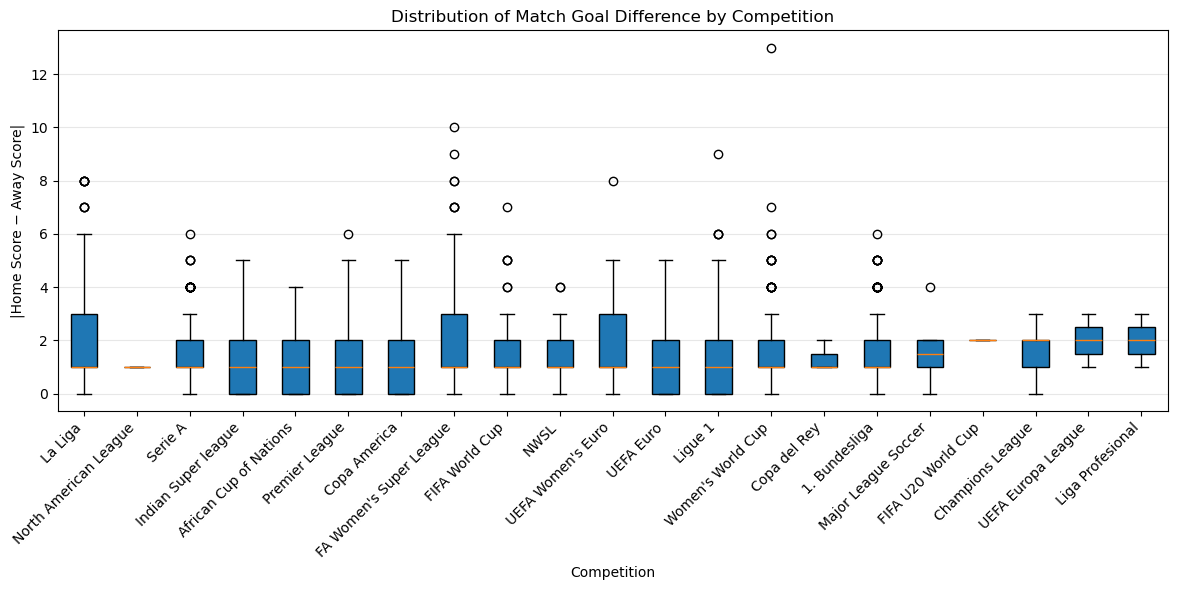

In [ ]:
# get score differential
match_df['goal_diff'] = (match_df['home_score'] - match_df['away_score']).abs()

competitions = match_df['competition'].unique()

data = [
    match_df.loc[match_df['competition'] == comp, 'goal_diff']
    for comp in competitions
]


# sort by median goal difference
competitions, data = zip(*sorted(
    zip(competitions, data),
    key=lambda x: x[1].median()
))


plt.figure(figsize=(12, 6))

plt.boxplot(
    data,
    labels=competitions,
    showfliers=True,
    patch_artist=True
)

plt.title('Distribution of Match Score by Competition')
plt.ylabel('|Home Score − Away Score|')
plt.xlabel('Competition')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Now that we've looked at the overall match data, I want to take a closer look at the events data. I will specifically look at the matches played during the 2022 Fifa World cup.

Notes:

https://github.com/statsbomb/open-data/blob/master/doc/Open%20Data%20Events%20v4.0.0.pdf
- events file name = match id
- so we need to filter the match ids for fifa world cup 2022 then look for those files in the events folder
- then we need to look through the 360 data and join the events and 360 data on event id

In [164]:
# look at sample event to understand available data
with open('statsbomb_data/data/events/3942227.json', 'r') as f:
    sample_event = json.load(f)

print(sample_event[0].keys())

dict_keys(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'type', 'possession', 'possession_team', 'play_pattern', 'team', 'duration', 'tactics'])


In [185]:
# this is the 360 data with x y coordinates
with open('statsbomb_data/data/three-sixty/3930180.json', 'r') as f:
    sample_event = json.load(f)

print(sample_event[0].keys())

dict_keys(['event_uuid', 'visible_area', 'freeze_frame'])


In [186]:
sample_event[0]

{'event_uuid': '55e7df33-7a8f-4d98-9fda-c5249b7a4f93',
 'visible_area': [21.394060374614487,
  80.0,
  43.631606565271625,
  0.0,
  78.12649982593994,
  0.0,
  99.946911002633,
  80.0,
  21.394060374614487,
  80.0],
 'freeze_frame': [{'teammate': True,
   'actor': False,
   'keeper': False,
   'location': [40.37973907545367, 30.533238184063563]},
  {'teammate': True,
   'actor': False,
   'keeper': False,
   'location': [41.65862773739556, 47.59957631090292]},
  {'teammate': True,
   'actor': False,
   'keeper': False,
   'location': [46.80318881508718, 38.975731396245315]},
  {'teammate': True,
   'actor': False,
   'keeper': False,
   'location': [52.511309984593865, 31.107787201496876]},
  {'teammate': True,
   'actor': False,
   'keeper': False,
   'location': [58.421362814313255, 64.99440024118593]},
  {'teammate': True,
   'actor': False,
   'keeper': False,
   'location': [60.773876598200054, 13.288799593142528]},
  {'teammate': True,
   'actor': True,
   'keeper': False,
   'lo

In [ ]:
fifa22_id = match_df[(match_df['competition']=='FIFA World Cup') & (match_df['season']=='2022')].index.to_list()
fifa22_id

events_dir = 'statsbomb_data/data/events'

events_data = []
test = None
for filename in os.listdir(events_dir):
    if filename.endswith(".json"): 
        with open(os.path.join(events_dir, filename)) as json_file:
            match_id = int(filename[:-5])
            if match_id in fifa22_id:
                data = json.load(json_file)
                for event in data:
                    ## only pull pass events
                    #if event['type']['name'] == 'Pass':
                        # need some logic for pass vs shot for some fields (easier to do outside the append)
                    #    outcome = event['pass']['outcome']['name'] if event['pass'].get('outcome') else 'Complete'
                    #    to = event['pass']['recipient']['name'] if event['pass'].get('recipient') else None
                    #    if outcome == "Complete" and to is not None:
                    #        test = event
                            events_data.append(
                                {
                                    'match_id': match_id,
                                    'event_order': event['index'],
                                    "period": event["period"],
                                    'timestamp': event['timestamp'],
                                    'type': event["type"],
                                    'team_id': event["team"]["id"],
                                    'possesion_team': event["possession_team"]["name"],
                                    'possession_id':event['possession_team']['id'],
                                    'play_pattern': event['play_pattern'],
                                    'from_position_x': event['location'][0],
                                }
                            )
# convert to dataframe
events_df = pd.DataFrame(events_data)

print('Done')
events_df.head()

KeyError: 'location'

In [ ]:
events_df